<a href="https://colab.research.google.com/github/IrutingaboRaissa/-machineLearningPipeline_formative2/blob/voice-verification-final/Formative_2_sounddataprocessing_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Formative 2 — Sound Data Processing Voiceprint Verification
Pipeline: Load/clean → Visualize → Augment → Manifest → Features → EDA → Train/Eval no leakage → Verify open-set → Simulation


Makes sure the environment has `librosa`, `soundfile`, `sklearn`, and others used in the notebook.

In [18]:
# %pip install -q librosa soundfile scikit-learn matplotlib pandas numpy


Loads required Python libraries and creates folders for raw audio, augmented data, figures, and outputs.


In [19]:
import os, re, json, pathlib, random, shutil
from collections import defaultdict
from pprint import pprint

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import librosa, librosa.display
import soundfile as sf

from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, log_loss, classification_report, confusion_matrix
import joblib
from IPython.display import display

# Paths
RAW_DIR = "data/audio"
AUG_DIR = "data/augmented"
FIG_DIR = "figures"
OUT_DIR = "outputs"
for d in [RAW_DIR, AUG_DIR, FIG_DIR, OUT_DIR]:
    os.makedirs(d, exist_ok=True)

# Globals
TARGET_SR = 16000
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE); random.seed(RANDOM_STATE)

print("Folders ready:")
print(" RAW_DIR:", os.path.abspath(RAW_DIR))
print(" AUG_DIR:", os.path.abspath(AUG_DIR))
print(" FIG_DIR:", os.path.abspath(FIG_DIR))
print(" OUT_DIR:", os.path.abspath(OUT_DIR))


Folders ready:
 RAW_DIR: /content/data/audio
 AUG_DIR: /content/data/augmented
 FIG_DIR: /content/figures
 OUT_DIR: /content/outputs


each team member’s audio clips

In [20]:

from google.colab import files
import os

UPLOAD_DIR = "data/audio"
os.makedirs(UPLOAD_DIR, exist_ok=True)

print(" Please choose your audio files (.wav, .m4a, .mp3, etc)...")
uploaded = files.upload()  # opens file picker


for name, data in uploaded.items():
    with open(os.path.join(UPLOAD_DIR, name), "wb") as f:
        f.write(data)
print(f"\nSaved {len(uploaded)} files to {UPLOAD_DIR}")


import pathlib
files_list = sorted([p.name for p in pathlib.Path(UPLOAD_DIR).glob("*")])
print("\nNow in data/audio:")
print(files_list)


 Please choose your audio files (.wav, .m4a, .mp3, etc)...


Saving elyse_confirm transaction .m4a to elyse_confirm transaction  (2).m4a
Saving elyse_yes approve.m4a to elyse_yes approve (2).m4a
Saving jabo_confirm transaction.m4a to jabo_confirm transaction (2).m4a
Saving jabo_yes approve .m4a to jabo_yes approve  (2).m4a
Saving raissa_confirm transaction.m4a to raissa_confirm transaction (2).m4a
Saving raissa_yes approve.m4a to raissa_yes approve (2).m4a
Saving solomon _yes approve a.m4a to solomon _yes approve a (2).m4a
Saving solomon_confirm transaction.m4a to solomon_confirm transaction (2).m4a

Saved 8 files to data/audio

Now in data/audio:
['elyse__confirm__1.wav', 'elyse__confirm__2.wav', 'elyse__yesapprove__1.wav', 'elyse__yesapprove__2.wav', 'elyse_confirm transaction  (1).m4a', 'elyse_confirm transaction  (2).m4a', 'elyse_confirm transaction .m4a', 'elyse_yes approve (1).m4a', 'elyse_yes approve (2).m4a', 'elyse_yes approve.m4a', 'jabo__confirm__1.wav', 'jabo__confirm__2.wav', 'jabo__yesapprove__1.wav', 'jabo__yesapprove__2.wav', 'ja

Lists all files

In [21]:
files = sorted([p.name for p in pathlib.Path(RAW_DIR).glob("*")])
print(f"Found {len(files)} file(s) in {RAW_DIR}:")
pprint(files)


Found 40 file(s) in data/audio:
['elyse__confirm__1.wav',
 'elyse__confirm__2.wav',
 'elyse__yesapprove__1.wav',
 'elyse__yesapprove__2.wav',
 'elyse_confirm transaction  (1).m4a',
 'elyse_confirm transaction  (2).m4a',
 'elyse_confirm transaction .m4a',
 'elyse_yes approve (1).m4a',
 'elyse_yes approve (2).m4a',
 'elyse_yes approve.m4a',
 'jabo__confirm__1.wav',
 'jabo__confirm__2.wav',
 'jabo__yesapprove__1.wav',
 'jabo__yesapprove__2.wav',
 'jabo_confirm transaction (1).m4a',
 'jabo_confirm transaction (2).m4a',
 'jabo_confirm transaction.m4a',
 'jabo_yes approve  (1).m4a',
 'jabo_yes approve  (2).m4a',
 'jabo_yes approve .m4a',
 'raissa__confirm__1.wav',
 'raissa__confirm__2.wav',
 'raissa__yesapprove__1.wav',
 'raissa__yesapprove__2.wav',
 'raissa_confirm transaction (1).m4a',
 'raissa_confirm transaction (2).m4a',
 'raissa_confirm transaction.m4a',
 'raissa_yes approve (1).m4a',
 'raissa_yes approve (2).m4a',
 'raissa_yes approve.m4a',
 'solomon _yes approve a (1).m4a',
 'solomon

Converts files to 16kHz mono WAVs, trims silence, normalizes volume, and renames them in a standard format: `speaker__phrase__index.wav`.

In [22]:
AUDIO_DIR = pathlib.Path(RAW_DIR)


SPEAKER_MAP = {
    "solomon": "solomon",
    "ama": "solomon",
    "elyse": "elyse",
    "elyes": "elyse",
    "jabo": "jabo",
    "raissa": "raissa",
}
PHRASE_MAP = {
    "yesapprove": ["yesapprove","yes approve","yes_approve","yes-approve","yes","approve","ok","okay"],
    "confirm":    ["confirm","confirm transaction","confirmation","verify","confirm_transaction","confirm-transaction"],
}

VALID_AUDIO_EXTS = (".wav",".mp3",".m4a",".flac",".opus",".aac")
DROP_EXTS = (".jpg",".jpeg",".png",".gif",".webp",".txt",".pdf",".csv",".md")

def guess_speaker(stem: str) -> str:
    s = stem.lower()
    for key, canonical in SPEAKER_MAP.items():
        if key in s:
            return canonical
    toks = [t for t in re.split(r"[^a-zA-Z]+", s) if len(t)>=2]
    return toks[0] if toks else "user"

def guess_phrase(stem: str) -> str:
    s = stem.lower()
    for canonical, keys in PHRASE_MAP.items():
        for k in keys:
            if k in s:
                return canonical
    return "yesapprove"

def clean_y(y):
    y, _ = librosa.effects.trim(y, top_db=30)
    if y.size:
        m = np.max(np.abs(y))
        if m > 0: y = y/m
    return y

def to_wav_16k(src: pathlib.Path) -> pathlib.Path:
    y, sr = librosa.load(str(src), sr=TARGET_SR, mono=True)
    y = clean_y(y)
    out = src.with_suffix(".wav")
    sf.write(str(out), y, TARGET_SR)
    return out

# 1) Remove obvious non-audio files
removed = 0
for p in list(AUDIO_DIR.glob("*")):
    if p.suffix.lower() in DROP_EXTS:
        p.unlink(missing_ok=True); removed += 1
if removed: print(f"Removed {removed} non-audio file(s).")

# 2) Convert any non-wavs to wav@16k
converted = 0
for p in list(AUDIO_DIR.glob("*")):
    if not p.is_file() or p.suffix.lower() not in VALID_AUDIO_EXTS:
        continue
    if p.suffix.lower() != ".wav":
        to_wav_16k(p); converted += 1
print("Converted to wav:", converted)

# 3) Continue indices from existing patterned wavs
from collections import defaultdict
counters = defaultdict(int)
for p in AUDIO_DIR.glob("*.wav"):
    parts = p.stem.split("__")
    if len(parts) == 3:
        sp, ph, idx = parts
        try: counters[(sp, ph)] = max(counters[(sp, ph)], int(idx))
        except: pass

def next_idx(sp, ph):
    counters[(sp, ph)] += 1
    return counters[(sp, ph)]

# 4) Enforce final naming pattern, apply remaps
renamed = 0; processed = 0
for p in sorted(AUDIO_DIR.glob("*.wav")):
    stem = re.sub(r"\s+", " ", p.stem).strip()

    if "__" in stem:
        # already looks patterned → still ensure canonical speaker
        try:
            sp, ph, idx = stem.split("__")
        except:
            sp, ph, idx = None, None, None
        canonical = SPEAKER_MAP.get(sp, sp)
        if canonical != sp:
            new_i = next_idx(canonical, ph)
            new_p = p.with_name(f"{canonical}__{ph}__{new_i}.wav")
            p.rename(new_p); renamed += 1
        else:
            try: counters[(sp, ph)] = max(counters[(sp, ph)], int(idx))
            except: pass
        processed += 1
        continue

    # Not patterned → guess speaker & phrase
    sp = guess_speaker(stem)
    ph = guess_phrase(stem)
    new_i = next_idx(sp, ph)
    new_p = p.with_name(f"{sp}__{ph}__{new_i}.wav")
    p.rename(new_p); renamed += 1; processed += 1

final_files = sorted([f.name for f in AUDIO_DIR.glob("*.wav")])
print(f"Processed: {processed} | Renamed: {renamed}")
print("Now in data/audio:")
pprint(final_files)


/tmp/ipython-input-763266951.py:44: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(str(src), sr=TARGET_SR, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipython-input-763266951.py:44: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(str(src), sr=TARGET_SR, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipython-input-763266951.py:44: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(str(src), sr=TARGET_SR, mono=True)
/us

Converted to wav: 24
Processed: 40 | Renamed: 24
Now in data/audio:
['elyse__confirm__1.wav',
 'elyse__confirm__2.wav',
 'elyse__confirm__3.wav',
 'elyse__confirm__4.wav',
 'elyse__confirm__5.wav',
 'elyse__yesapprove__1.wav',
 'elyse__yesapprove__2.wav',
 'elyse__yesapprove__3.wav',
 'elyse__yesapprove__4.wav',
 'elyse__yesapprove__5.wav',
 'jabo__confirm__1.wav',
 'jabo__confirm__2.wav',
 'jabo__confirm__3.wav',
 'jabo__confirm__4.wav',
 'jabo__confirm__5.wav',
 'jabo__yesapprove__1.wav',
 'jabo__yesapprove__2.wav',
 'jabo__yesapprove__3.wav',
 'jabo__yesapprove__4.wav',
 'jabo__yesapprove__5.wav',
 'raissa__confirm__1.wav',
 'raissa__confirm__2.wav',
 'raissa__confirm__3.wav',
 'raissa__confirm__4.wav',
 'raissa__confirm__5.wav',
 'raissa__yesapprove__1.wav',
 'raissa__yesapprove__2.wav',
 'raissa__yesapprove__3.wav',
 'raissa__yesapprove__4.wav',
 'raissa__yesapprove__5.wav',
 'solomon__confirm__1.wav',
 'solomon__confirm__2.wav',
 'solomon__confirm__3.wav',
 'solomon__confirm__4.w

/tmp/ipython-input-763266951.py:44: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(str(src), sr=TARGET_SR, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Prints detected speakers to confirm  dataset includes all four team members.

In [23]:
rows = []
for p in sorted(pathlib.Path(RAW_DIR).glob("*.wav")):
    sp, ph, idx = p.stem.split("__")
    y, sr = librosa.load(str(p), sr=TARGET_SR, mono=True)
    y, _ = librosa.effects.trim(y, top_db=30)
    dur = len(y)/TARGET_SR if len(y) else 0.0
    rms = float(librosa.feature.rms(y=y if len(y) else np.zeros(1)).mean())
    rows.append({"file": p.name, "speaker": sp, "phrase": ph, "idx": int(idx),
                 "dur_s": round(dur,3), "rms": round(rms,4)})

aud_df = pd.DataFrame(rows).sort_values(["speaker","phrase","idx"])
display(aud_df)
print("\nCounts by speaker:\n", aud_df["speaker"].value_counts())
print("\nCounts by phrase:\n", aud_df["phrase"].value_counts())


,file,speaker,phrase,idx,dur_s,rms
0,elyse__confirm__1.wav,elyse,confirm,1,3.019,0.1398
1,elyse__confirm__2.wav,elyse,confirm,2,3.019,0.1398
2,elyse__confirm__3.wav,elyse,confirm,3,3.019,0.1398
3,elyse__confirm__4.wav,elyse,confirm,4,3.019,0.1398
4,elyse__confirm__5.wav,elyse,confirm,5,3.019,0.1398
5,elyse__yesapprove__1.wav,elyse,yesapprove,1,1.643,0.0830
6,elyse__yesapprove__2.wav,elyse,yesapprove,2,1.643,0.0830
7,elyse__yesapprove__3.wav,elyse,yesapprove,3,1.643,0.0830
8,elyse__yesapprove__4.wav,elyse,yesapprove,4,1.643,0.0830
9,elyse__yesapprove__5.wav,elyse,yesapprove,5,1.643,0.0830



Counts by speaker:
 speaker
elyse      10
jabo       10
raissa     10
solomon    10
Name: count, dtype: int64

Counts by phrase:
 phrase
confirm       20
yesapprove    20
Name: count, dtype: int64


Generates waveform and spectrogram plots for a few clips per speaker

In [24]:
def save_plots(filepath, out_dir=FIG_DIR):
    y, sr = librosa.load(filepath, sr=TARGET_SR, mono=True)
    y, _ = librosa.effects.trim(y, top_db=30)
    if y.size:
        m = np.max(np.abs(y));
        if m > 0: y = y/m
    base = os.path.splitext(os.path.basename(filepath))[0]

    # Waveform
    plt.figure(figsize=(10,3))
    librosa.display.waveshow(y, sr=sr)
    plt.title(f"Waveform – {base}")
    plt.tight_layout()
    out_wave = os.path.join(out_dir, f"{base}_wave.png")
    plt.savefig(out_wave, dpi=150); plt.close()

    # Spectrogram
    S = np.abs(librosa.stft(y, n_fft=1024, hop_length=256))
    D = librosa.amplitude_to_db(S, ref=np.max)
    plt.figure(figsize=(10,3))
    librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='hz', hop_length=256)
    plt.title(f"Spectrogram – {base}")
    plt.colorbar(format='%+2.0f dB'); plt.tight_layout()
    out_spec = os.path.join(out_dir, f"{base}_spec.png")
    plt.savefig(out_spec, dpi=150); plt.close()
    return out_wave, out_spec

saved = 0
for sp, grp in aud_df.groupby("speaker"):
    for f in grp["file"].head(2):
        save_plots(os.path.join(RAW_DIR, f)); saved += 1
print(f"Saved {saved*2} figures (waveform+spectrogram) into {FIG_DIR}")


Saved 16 figures (waveform+spectrogram) into figures


Builds a table of all audio files and applies pitch shift, time stretch, and background noise to expand the dataset.


In [25]:
shutil.rmtree(AUG_DIR, ignore_errors=True)
os.makedirs(AUG_DIR, exist_ok=True)

manifest = []

def _write_aug(y_out, sr, name, tag):
    out = os.path.join(AUG_DIR, f"{name}__aug-{tag}.wav")
    sf.write(out, y_out, sr); return out

for f in sorted([*pathlib.Path(RAW_DIR).glob("*.wav")]):
    fp = str(f); name = f.stem
    speaker, phrase, idx = name.split("__")
    y, sr = librosa.load(fp, sr=TARGET_SR, mono=True)
    y, _ = librosa.effects.trim(y, top_db=30)
    if y.size:
        m = np.max(np.abs(y));
        if m > 0: y = y/m

    # original
    manifest.append({
        "filepath": fp, "speaker": speaker, "phrase": phrase,
        "is_augmented": 0, "aug_type": "none", "base_id": name,
        "sr": sr, "duration_sec": len(y)/sr
    })

    # pitch ±2
    n_steps = random.choice([+2, -2])
    y_pitch = librosa.effects.pitch_shift(y, sr=sr, n_steps=n_steps)
    y_pitch = y_pitch/(np.max(np.abs(y_pitch)) or 1.0)
    fp1 = _write_aug(y_pitch, sr, name, f"pitch{n_steps:+d}")
    manifest.append({"filepath": fp1, "speaker": speaker, "phrase": phrase,
                     "is_augmented":1, "aug_type":f"pitch{n_steps:+d}",
                     "base_id": name, "sr": sr, "duration_sec": len(y)/sr})

    # stretch 0.9/1.1
    rate = random.choice([0.9, 1.1])
    y_stretch = librosa.effects.time_stretch(y, rate=rate)
    y_stretch = y_stretch/(np.max(np.abs(y_stretch)) or 1.0)
    fp2 = _write_aug(y_stretch, sr, name, f"stretch{rate}")
    manifest.append({"filepath": fp2, "speaker": speaker, "phrase": phrase,
                     "is_augmented":1, "aug_type":f"stretch{rate}",
                     "base_id": name, "sr": sr, "duration_sec": len(y)/sr})

    # noise @ 5/10/15 dB SNR
    snr_db = random.choice([5, 10, 15])
    noise = np.random.randn(len(y)); noise = noise/(np.max(np.abs(noise)) or 1.0)
    alpha = 10**(-snr_db/20)
    y_noise = y + alpha*noise
    y_noise = y_noise/(np.max(np.abs(y_noise)) or 1.0)
    fp3 = _write_aug(y_noise, sr, name, f"noise_snr{snr_db}")
    manifest.append({"filepath": fp3, "speaker": speaker, "phrase": phrase,
                     "is_augmented":1, "aug_type":f"noise_snr{snr_db}",
                     "base_id": name, "sr": sr, "duration_sec": len(y)/sr})

manifest_df = pd.DataFrame(manifest)
man_csv = os.path.join(OUT_DIR, "manifest_audio.csv")
manifest_df.to_csv(man_csv, index=False)
print("Saved manifest:", man_csv, "| rows:", len(manifest_df))
display(manifest_df.head())
print("\nSpeakers in manifest:", manifest_df['speaker'].unique())
print("Counts by speaker:\n", manifest_df['speaker'].value_counts())


Saved manifest: outputs/manifest_audio.csv | rows: 160


,filepath,speaker,phrase,is_augmented,aug_type,base_id,sr,duration_sec
0,data/audio/elyse__confirm__1.wav,elyse,confirm,0,none,elyse__confirm__1,16000,3.018687
1,data/augmented/elyse__confirm__1__aug-pitch+2.wav,elyse,confirm,1,pitch+2,elyse__confirm__1,16000,3.018687
2,data/augmented/elyse__confirm__1__aug-stretch0...,elyse,confirm,1,stretch0.9,elyse__confirm__1,16000,3.018687
3,data/augmented/elyse__confirm__1__aug-noise_sn...,elyse,confirm,1,noise_snr15,elyse__confirm__1,16000,3.018687
4,data/audio/elyse__confirm__2.wav,elyse,confirm,0,none,elyse__confirm__2,16000,3.018687



Speakers in manifest: ['elyse' 'jabo' 'raissa' 'solomon']
Counts by speaker:
 speaker
elyse      40
jabo       40
raissa     40
solomon    40
Name: count, dtype: int64


Shows summary counts per speaker and plots duration distribution and feature correlations.

In [26]:
def extract_features(path):
    y, sr = librosa.load(path, sr=TARGET_SR, mono=True)
    y, _ = librosa.effects.trim(y, top_db=30)
    if y.size:
        m = np.max(np.abs(y));
        if m > 0: y = y/m
    if not y.size:
        raise ValueError(f"Empty after trim: {path}")

    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    dmfcc = librosa.feature.delta(mfcc)
    ddmfcc = librosa.feature.delta(mfcc, order=2)

    feats = {}
    for i,v in enumerate(mfcc.mean(axis=1)): feats[f"mfcc_mean_{i+1}"]=float(v)
    for i,v in enumerate(mfcc.std(axis=1)):  feats[f"mfcc_std_{i+1}"]=float(v)
    for i,v in enumerate(dmfcc.mean(axis=1)): feats[f"dmfcc_mean_{i+1}"]=float(v)
    for i,v in enumerate(ddmfcc.mean(axis=1)): feats[f"ddmfcc_mean_{i+1}"]=float(v)
    feats["rms"]=float(librosa.feature.rms(y=y).mean())
    feats["rolloff"]=float(librosa.feature.spectral_rolloff(y=y, sr=sr).mean())
    feats["centroid"]=float(librosa.feature.spectral_centroid(y=y, sr=sr).mean())
    feats["bandwidth"]=float(librosa.feature.spectral_bandwidth(y=y, sr=sr).mean())
    feats["zcr"]=float(librosa.feature.zero_crossing_rate(y).mean())
    return feats

rows = []
for fp in manifest_df["filepath"]:
    feats = extract_features(fp)
    meta = manifest_df.loc[manifest_df["filepath"]==fp].iloc[0].to_dict()
    rows.append({**meta, **feats})

features_df = pd.DataFrame(rows)
feat_csv = os.path.join(OUT_DIR, "audio_features.csv")
features_df.to_csv(feat_csv, index=False)
print("Saved features:", feat_csv, "| shape:", features_df.shape)
display(features_df.head())


Saved features: outputs/audio_features.csv | shape: (160, 65)


,filepath,speaker,phrase,is_augmented,aug_type,base_id,sr,duration_sec,mfcc_mean_1,mfcc_mean_2,...,ddmfcc_mean_9,ddmfcc_mean_10,ddmfcc_mean_11,ddmfcc_mean_12,ddmfcc_mean_13,rms,rolloff,centroid,bandwidth,zcr
0,data/audio/elyse__confirm__1.wav,elyse,confirm,0,none,elyse__confirm__1,16000,3.018687,-197.268875,76.725273,...,-0.037112,-0.010992,0.001185,-0.092148,-0.035113,0.139820,3696.463816,1663.773795,1909.331424,0.079626
1,data/augmented/elyse__confirm__1__aug-pitch+2.wav,elyse,confirm,1,pitch+2,elyse__confirm__1,16000,3.018687,-204.922623,74.830933,...,-0.044491,0.009153,-0.061111,-0.107269,0.006786,0.129255,3752.713816,1665.380367,1985.930583,0.079086
2,data/augmented/elyse__confirm__1__aug-stretch0...,elyse,confirm,1,stretch0.9,elyse__confirm__1,16000,3.018687,-196.817001,74.839813,...,-0.056960,-0.025876,-0.020308,-0.114150,-0.063183,0.142361,3754.241071,1667.818607,1944.670314,0.074851
3,data/augmented/elyse__confirm__1__aug-noise_sn...,elyse,confirm,1,noise_snr15,elyse__confirm__1,16000,3.018687,-66.505707,22.708082,...,-0.001956,-0.018314,-0.121803,-0.052060,0.002049,0.144261,6337.582237,3221.103897,2457.018578,0.232499
4,data/audio/elyse__confirm__2.wav,elyse,confirm,0,none,elyse__confirm__2,16000,3.018687,-197.268875,76.725273,...,-0.037112,-0.010992,0.001185,-0.092148,-0.035113,0.139820,3696.463816,1663.773795,1909.331424,0.079626


Trains a Random Forest on extracted features, evaluates Accuracy, F1, and Log Loss, and saves the model + confusion matrix

,filepath,speaker,phrase,is_augmented,aug_type,base_id,sr,duration_sec,mfcc_mean_1,mfcc_mean_2,...,ddmfcc_mean_9,ddmfcc_mean_10,ddmfcc_mean_11,ddmfcc_mean_12,ddmfcc_mean_13,rms,rolloff,centroid,bandwidth,zcr
0,data/audio/elyse__confirm__1.wav,elyse,confirm,0,none,elyse__confirm__1,16000,3.018687,-197.268875,76.725273,...,-0.037112,-0.010992,0.001185,-0.092148,-0.035113,0.139820,3696.463816,1663.773795,1909.331424,0.079626
1,data/augmented/elyse__confirm__1__aug-pitch+2.wav,elyse,confirm,1,pitch+2,elyse__confirm__1,16000,3.018687,-204.922623,74.830933,...,-0.044491,0.009153,-0.061111,-0.107269,0.006786,0.129255,3752.713816,1665.380367,1985.930583,0.079086
2,data/augmented/elyse__confirm__1__aug-stretch0...,elyse,confirm,1,stretch0.9,elyse__confirm__1,16000,3.018687,-196.817001,74.839813,...,-0.056960,-0.025876,-0.020308,-0.114150,-0.063183,0.142361,3754.241071,1667.818607,1944.670314,0.074851
3,data/augmented/elyse__confirm__1__aug-noise_sn...,elyse,confirm,1,noise_snr15,elyse__confirm__1,16000,3.018687,-66.505707,22.708082,...,-0.001956,-0.018314,-0.121803,-0.052060,0.002049,0.144261,6337.582237,3221.103897,2457.018578,0.232499
4,data/audio/elyse__confirm__2.wav,elyse,confirm,0,none,elyse__confirm__2,16000,3.018687,-197.268875,76.725273,...,-0.037112,-0.010992,0.001185,-0.092148,-0.035113,0.139820,3696.463816,1663.773795,1909.331424,0.079626



Summary by speaker:


,count
speaker,
elyse,40
jabo,40
raissa,40
solomon,40


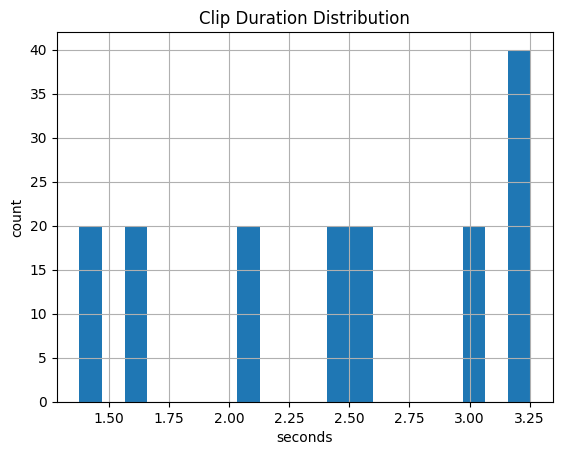

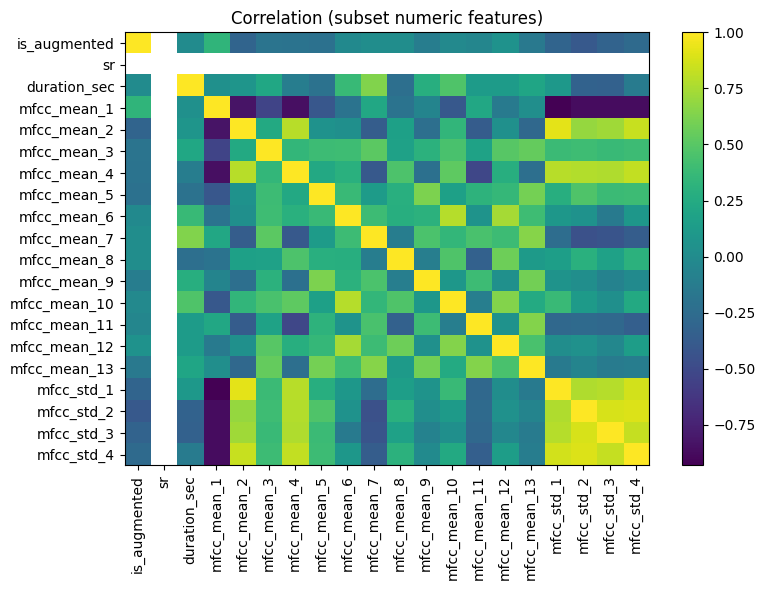

In [27]:
display(features_df.head())
print("\nSummary by speaker:")
display(features_df.groupby("speaker").size().to_frame("count"))

# Plot 1: Duration distribution
plt.figure()
features_df["duration_sec"].hist(bins=20)
plt.title("Clip Duration Distribution"); plt.xlabel("seconds"); plt.ylabel("count")
plt.show()

# Plot 2: Correlation heatmap
num_cols = features_df.select_dtypes(include=[np.number]).columns.tolist()[:20]
corr = features_df[num_cols].corr()
plt.figure(figsize=(8,6))
im = plt.imshow(corr, aspect='auto')
plt.colorbar(im); plt.title("Correlation (subset numeric features)")
plt.xticks(range(len(num_cols)), num_cols, rotation=90)
plt.yticks(range(len(num_cols)), num_cols)
plt.tight_layout(); plt.show()


Runs `verify_voice()`

In [31]:
def grouped_split_all_classes(X, y, groups, train_size=0.7, max_tries=200, min_test_classes=2):
    """Try multiple grouped splits until test has at least `min_test_classes` distinct labels."""
    labels = np.array(y)
    gss = GroupShuffleSplit(n_splits=max_tries, train_size=train_size, random_state=RANDOM_STATE)
    for train_idx, test_idx in gss.split(X, y, groups):
        if len(np.unique(labels[test_idx])) >= min_test_classes:
            return train_idx, test_idx

    unique_groups = np.unique(groups)
    for train_idx, test_idx in GroupKFold(n_splits=min(5, len(unique_groups))).split(X, y, groups):
        if len(np.unique(labels[test_idx])) >= min_test_classes:
            return train_idx, test_idx

    return train_idx, test_idx


In [32]:
X = features_df.drop(columns=["filepath","speaker","phrase","is_augmented","aug_type","base_id","sr","duration_sec"])
y = features_df["speaker"].astype(str)
groups = features_df["base_id"].astype(str)

train_idx, test_idx = grouped_split_all_classes(X, y, groups, train_size=0.7, max_tries=200, min_test_classes=2)
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

pipe = make_pipeline(
    StandardScaler(with_mean=False),
    RandomForestClassifier(n_estimators=400, random_state=RANDOM_STATE, class_weight="balanced")
)
pipe.fit(X_train, y_train)

# Metrics
classes_all = pipe.classes_
proba = pipe.predict_proba(X_test)
preds = classes_all[np.argmax(proba, axis=1)]

acc = accuracy_score(y_test, preds)
f1w = f1_score(y_test, preds, average="weighted")
ll = log_loss(y_test, proba, labels=classes_all)

print(f"Accuracy: {acc:.3f} | F1(weighted): {f1w:.3f} | LogLoss: {ll:.3f}\n")
print(classification_report(y_test, preds, labels=classes_all, zero_division=0))

cm = confusion_matrix(y_test, preds, labels=classes_all)
fig, ax = plt.subplots(figsize=(6,6))
im = ax.imshow(cm, cmap="Blues")
ax.set_title("Confusion Matrix")
ax.set_xticks(range(len(classes_all))); ax.set_xticklabels(classes_all, rotation=90)
ax.set_yticks(range(len(classes_all))); ax.set_yticklabels(classes_all)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center", color="black")
fig.colorbar(im); plt.tight_layout()
cm_path = os.path.join(FIG_DIR, "confusion_matrix.png")
plt.savefig(cm_path, dpi=150); plt.close()
print("Saved confusion matrix ->", cm_path)

joblib.dump(pipe, os.path.join(OUT_DIR, "voiceprint_model.pkl"))
with open(os.path.join(OUT_DIR, "feature_columns.json"), "w") as f:
    json.dump(list(X.columns), f)
print("Saved model & feature columns ->", OUT_DIR)


Accuracy: 1.000 | F1(weighted): 1.000 | LogLoss: 0.234

              precision    recall  f1-score   support

       elyse       1.00      1.00      1.00        12
        jabo       1.00      1.00      1.00        16
      raissa       1.00      1.00      1.00        12
     solomon       1.00      1.00      1.00         8

    accuracy                           1.00        48
   macro avg       1.00      1.00      1.00        48
weighted avg       1.00      1.00      1.00        48

Saved confusion matrix -> figures/confusion_matrix.png
Saved model & feature columns -> outputs


In [36]:
THRESH = 0.70  # adjust to ~0.60 if clips are very quiet/short

def extract_features_single(path, cols_path=os.path.join(OUT_DIR, "feature_columns.json")):
    y, sr = librosa.load(path, sr=TARGET_SR, mono=True)
    y, _ = librosa.effects.trim(y, top_db=30)
    if y.size:
        m = np.max(np.abs(y));
        if m > 0: y = y/m

    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    dmfcc = librosa.feature.delta(mfcc); ddmfcc = librosa.feature.delta(mfcc, order=2)

    feats = {}
    for i,v in enumerate(mfcc.mean(axis=1)): feats[f"mfcc_mean_{i+1}"]=float(v)
    for i,v in enumerate(mfcc.std(axis=1)):  feats[f"mfcc_std_{i+1}"]=float(v)
    for i,v in enumerate(dmfcc.mean(axis=1)): feats[f"dmfcc_mean_{i+1}"]=float(v)
    for i,v in enumerate(ddmfcc.mean(axis=1)): feats[f"ddmfcc_mean_{i+1}"]=float(v)
    feats["rms"]=float(librosa.feature.rms(y=y).mean())
    feats["rolloff"]=float(librosa.feature.spectral_rolloff(y=y, sr=sr).mean())
    feats["centroid"]=float(librosa.feature.spectral_centroid(y=y, sr=sr).mean())
    feats["bandwidth"]=float(librosa.feature.spectral_bandwidth(y=y, sr=sr).mean())
    feats["zcr"]=float(librosa.feature.zero_crossing_rate(y).mean())

    with open(cols_path, "r") as f:
        cols = json.load(f)
    x = pd.DataFrame([feats])
    for c in cols:
        if c not in x.columns: x[c] = 0.0
    x = x[cols]
    return x

def verify_voice(sample_path, claimed_speaker=None, threshold=THRESH):
    pipe = joblib.load(os.path.join(OUT_DIR, "voiceprint_model.pkl"))
    x = extract_features_single(sample_path)
    proba = pipe.predict_proba(x)[0]
    classes = pipe.classes_
    top_idx = int(np.argmax(proba))
    top_cls, top_p = classes[top_idx], float(proba[top_idx])

    if top_p < threshold:
        return {"decision":"REJECT (unknown)", "top_class":top_cls, "confidence":round(top_p,3)}
    if claimed_speaker is None or claimed_speaker == top_cls:
        return {"decision":"ACCEPT", "speaker":top_cls, "confidence":round(top_p,3)}
    return {"decision":"REJECT (mismatch)", "predicted":top_cls, "claimed":claimed_speaker, "confidence":round(top_p,3)}

def simulate_transaction(face_ok=True, voice_path=None, claimed=None, threshold=THRESH):
    print("Face check:", "PASS" if face_ok else "FAIL")
    if not face_ok:
        print("Access denied before product model.\n")
        return {"face":"FAIL","voice":None,"result":"DENIED"}
    if voice_path is None:
        print("No voice sample → DENIED\n")
        return {"face":"PASS","voice":None,"result":"DENIED"}

    v = verify_voice(voice_path, claimed_speaker=claimed, threshold=threshold)
    print("Voice:", v)
    if v["decision"].startswith("ACCEPT"):
        print("Product model: ALLOWED (simulate recommendation)\n")
        return {"face":"PASS","voice":"ACCEPT","result":"ALLOWED"}
    else:
        print("Access denied (unauthorized attempt).\n")
        return {"face":"PASS","voice":"REJECT","result":"DENIED"}




In [37]:
# Authorized example — should ACCEPT
verify_voice("data/audio/elyse__confirm__1.wav", claimed_speaker="elyse")

#  Unauthorized attempt — should REJECT
simulate_transaction(
    face_ok=True,
    voice_path="data/audio/elyse__confirm__1.wav",
    claimed="solomon",
    threshold=0.7
)


Face check: PASS
Voice: {'decision': 'REJECT (mismatch)', 'predicted': 'elyse', 'claimed': 'solomon', 'confidence': 1.0}
Access denied (unauthorized attempt).



{'face': 'PASS', 'voice': 'REJECT', 'result': 'DENIED'}